In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.backends.backend_pdf import PdfPages

# Style
sns.set_style("whitegrid")

# Load dataset
df = pd.read_csv("/content/placement_predict_50k Dataset.csv")

# Basic Information
print("First 5 rows of the dataset:")
print(df.head())

print("\nShape of dataset:", df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types and non-null counts:")
df.info()

print("\nMissing values per column:")
print(df.isnull().sum())

# Create Placement Flag
df["Placed_Flag"] = df["PlacementStatus"].apply(
    lambda x: 1 if x == "Placed" else 0
)

# Numerical columns
num_cols = [
    "CGPA",
    "AttendancePercent",
    "AptitudeTestScore",
    "CodingTestScore",
    "SoftSkillsRating",
    "Salary Package"
]

# ----------------------------------------
# Figure 1: Missing Values Heatmap
# ----------------------------------------
fig1 = plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=False, cmap="viridis", yticklabels=False)
plt.title("Missingness Heatmap")
plt.xlabel("Columns")
plt.tight_layout()
plt.show()

# ----------------------------------------
# Figure 2: Histograms
# ----------------------------------------
fig2, axes = plt.subplots(2, 3, figsize=(15, 8))

for i, column in enumerate(num_cols):
    row, col = divmod(i, 3)
    sns.histplot(df[column], bins=20, kde=True, ax=axes[row, col])
    axes[row, col].set_title(column)

plt.tight_layout()
plt.show()

# ----------------------------------------
# Figure 3: Placement Rate by Stream
# ----------------------------------------
fig3 = plt.figure(figsize=(10, 6))

placement_rate = (
    df.groupby("Stream")["Placed_Flag"]
      .mean()
      .sort_values(ascending=False) * 100
)

sns.barplot(
    x=placement_rate.index,
    y=placement_rate.values,
    palette="crest"
)

plt.title("Placement Rate (%) by Stream")
plt.xlabel("Stream")
plt.ylabel("Placement Rate (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("\nPlacement Rate (%) by Stream:")
print(placement_rate.round(2))

# ----------------------------------------
# Figure 4: Correlation Heatmap
# ----------------------------------------
fig4 = plt.figure(figsize=(10, 8))

numeric_df = df.select_dtypes(include=["int64", "float64"])
corr_matrix = numeric_df.corr()

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    square=True,
    linewidths=0.5
)

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

# ----------------------------------------
# Figure 5: Boxplots
# ----------------------------------------
fig5, axes5 = plt.subplots(2, 3, figsize=(15, 8))

for i, column in enumerate(num_cols):
    row, col = divmod(i, 3)
    sns.boxplot(y=df[column], ax=axes5[row, col], color="lightcoral")
    axes5[row, col].set_title(column)

plt.tight_layout()
plt.show()

# ----------------------------------------
# Save all figures to PDF
# ----------------------------------------
pdf = PdfPages("EDA_Report.pdf")

pdf.savefig(fig1)
pdf.savefig(fig2)
pdf.savefig(fig3)
pdf.savefig(fig4)
pdf.savefig(fig5)

pdf.close()

print("\nEDA_Report.pdf created successfully with 5 pages!")

FileNotFoundError: [Errno 2] No such file or directory: '/content/placement_predict_50k Dataset.csv'

Saving placement_predict_50k Dataset.csv to placement_predict_50k Dataset.csv
FIRST 5 ROWS
   StudentID  Gender       City CollegeTier Stream Specialisation Hostel  \
0          1    Male  Ahmedabad       Tier2    ECE     Networking     No   
1          2  Female     Mumbai       Tier2    ECE    DataScience    Yes   
2          3    Male    Kolkata       Tier2     IT    DataScience    Yes   
3          4    Male     Jaipur       Tier1     CS             AI     No   
4          5    Male       Pune       Tier2     IT    DataScience    Yes   

  HistoryOfBacklogs  SGPA_Sem1  SGPA_Sem2  ...  Publications  \
0                No       6.02       6.54  ...             0   
1               Yes       5.84       5.12  ...             0   
2                No       4.91       5.29  ...             0   
3                No       7.67       8.03  ...             0   
4                No       8.14       8.97  ...             1   

   AptitudeTestScore  SoftSkillsRating  CodingTestScore  MockInterv

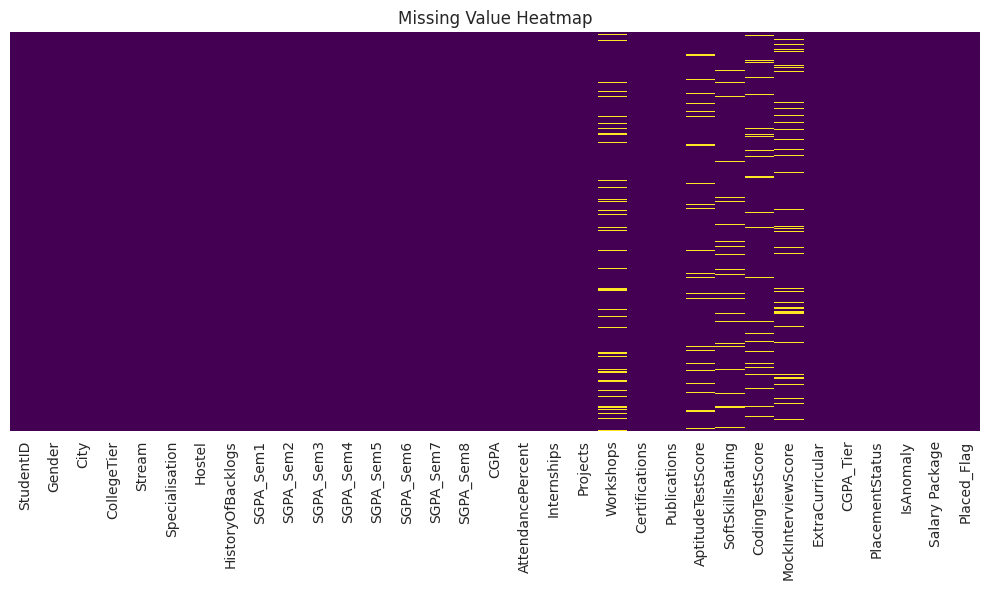

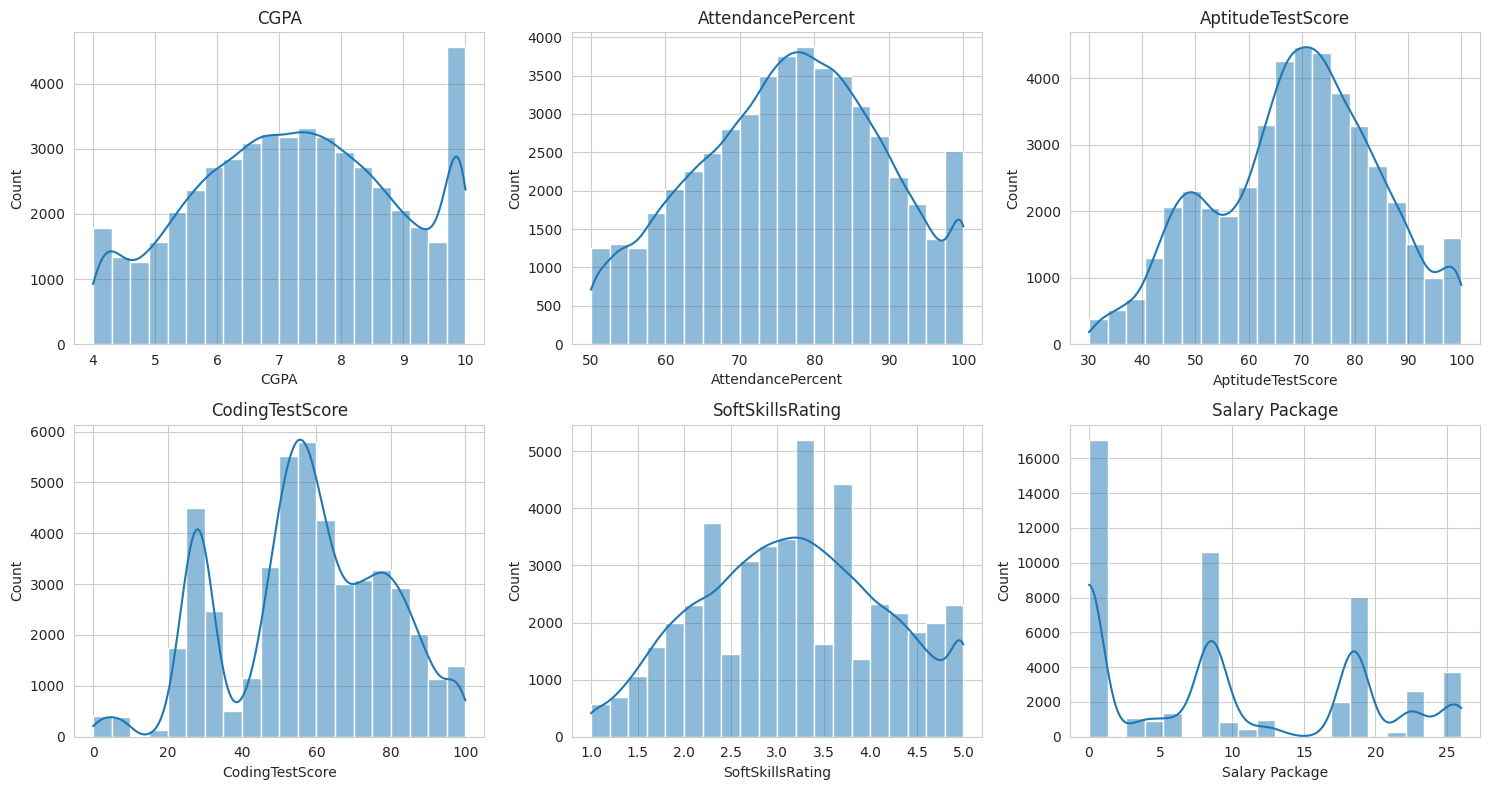

/tmp/ipykernel_3516/3149995788.py:120: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


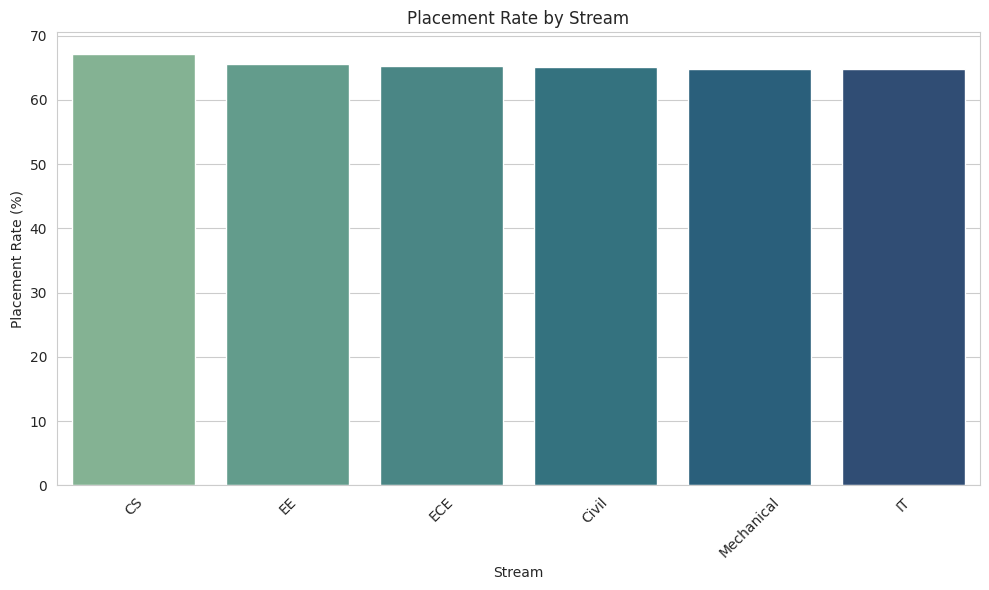


Placement Rate by Stream
Stream
CS            67.17
EE            65.64
ECE           65.32
Civil         65.15
Mechanical    64.88
IT            64.86
Name: Placed_Flag, dtype: float64


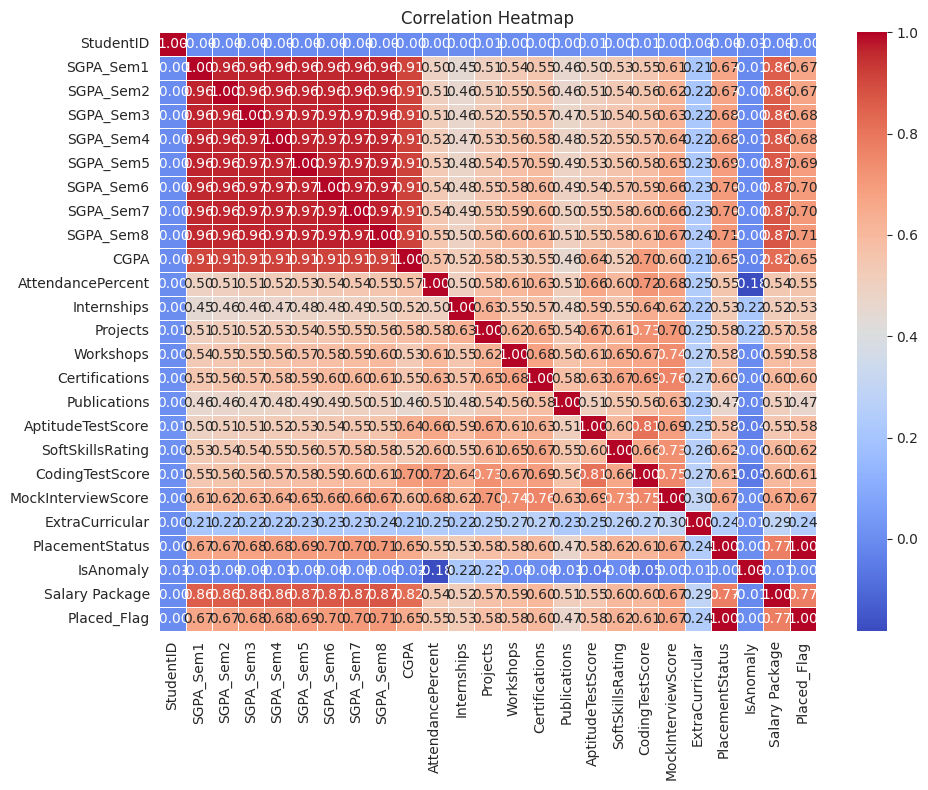

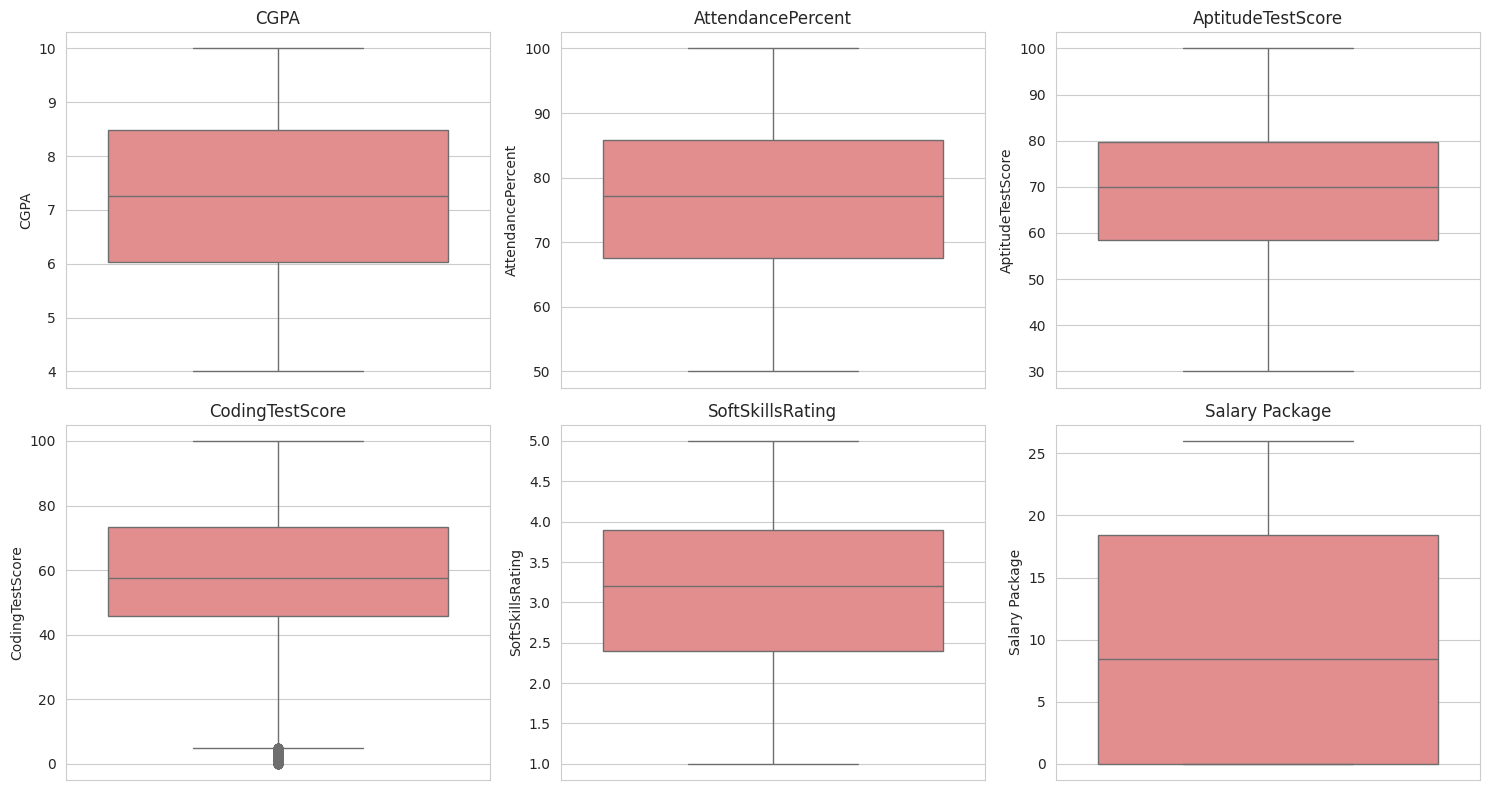

In [ ]:
# ==========================================================
# EXPERIMENT 2 - PLACEMENT PREDICTION EDA
# ==========================================================

# Upload dataset (Google Colab)
from google.colab import files
uploaded = files.upload()

# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.backends.backend_pdf import PdfPages

# Style
sns.set_style("whitegrid")

# Read dataset
df = pd.read_csv(next(iter(uploaded)))

# ----------------------------------------------------------
# Display basic information
# ----------------------------------------------------------
print("FIRST 5 ROWS")
print(df.head())

print("\nDATASET SHAPE")
print(df.shape)

print("\nCOLUMN NAMES")
print(df.columns.tolist())

print("\nDATA TYPES")
df.info()

print("\nMISSING VALUES")
print(df.isnull().sum())

# ----------------------------------------------------------
# Remove extra spaces from column names
# ----------------------------------------------------------
df.columns = df.columns.str.strip()

# ----------------------------------------------------------
# Create Placement Flag
# Works for both text and numeric datasets
# ----------------------------------------------------------
if df["PlacementStatus"].dtype == "object":
    df["Placed_Flag"] = df["PlacementStatus"].str.strip().str.lower().map({
        "placed": 1,
        "not placed": 0
    })
else:
    df["Placed_Flag"] = df["PlacementStatus"]

# ----------------------------------------------------------
# Numerical columns
# ----------------------------------------------------------
num_cols = [
    "CGPA",
    "AttendancePercent",
    "AptitudeTestScore",
    "CodingTestScore",
    "SoftSkillsRating",
    "Salary Package"
]

# Keep only columns that actually exist
num_cols = [col for col in num_cols if col in df.columns]

# ==========================================================
# FIGURE 1 - Missing Value Heatmap
# ==========================================================
fig1 = plt.figure(figsize=(10,6))

sns.heatmap(
    df.isnull(),
    cmap="viridis",
    cbar=False,
    yticklabels=False
)

plt.title("Missing Value Heatmap")
plt.tight_layout()
plt.show()

# ==========================================================
# FIGURE 2 - Histograms
# ==========================================================
fig2, axes = plt.subplots(2,3,figsize=(15,8))

axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(
        df[col].dropna(),
        bins=20,
        kde=True,
        ax=axes[i]
    )
    axes[i].set_title(col)

for j in range(len(num_cols),6):
    fig2.delaxes(axes[j])

plt.tight_layout()
plt.show()

# ==========================================================
# FIGURE 3 - Placement Rate by Stream
# ==========================================================
fig3 = plt.figure(figsize=(10,6))

placement_rate = (
    df.groupby("Stream")["Placed_Flag"]
    .mean()*100
).sort_values(ascending=False)

sns.barplot(
    x=placement_rate.index,
    y=placement_rate.values,
    palette="crest"
)

plt.title("Placement Rate by Stream")
plt.xlabel("Stream")
plt.ylabel("Placement Rate (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("\nPlacement Rate by Stream")
print(placement_rate.round(2))

# ==========================================================
# FIGURE 4 - Correlation Heatmap
# ==========================================================
fig4 = plt.figure(figsize=(10,8))

numeric_df = df.select_dtypes(include=np.number)

corr = numeric_df.corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

# ==========================================================
# FIGURE 5 - Boxplots
# ==========================================================
fig5, axes = plt.subplots(2,3,figsize=(15,8))

axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(
        y=df[col],
        ax=axes[i],
        color="lightcoral"
    )
    axes[i].set_title(col)

for j in range(len(num_cols),6):
    fig5.delaxes(axes[j])

plt.tight_layout()
plt.show()

# ==========================================================
# Save all figures into PDF
# ==========================================================
pdf = PdfPages("EDA_Report.pdf")

pdf.savefig(fig1)
pdf.savefig(fig2)
pdf.savefig(fig3)
pdf.savefig(fig4)
pdf.savefig(fig5)

pdf.close()

print("\nEDA_Report.pdf created successfully!")

# ==========================================================
# Download PDF
# ==========================================================
files.download("EDA_Report.pdf")